In [1]:
import os
import json
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from tqdm import tqdm
import matplotlib.ticker as ticker
import torchvision

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from torch.utils.data import DataLoader, TensorDataset

In [2]:
LEARNING_RATE = 0.0001
BATCH_SIZE = 64
L2_LAMBDA = 0.001
EPOCHS = 100
SEED = 42

In [3]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [4]:
set_seed(SEED)

dataset = fetch_openml(
    name="mushroom",
    version=1,
    as_frame=True,
    data_home="datasets"
)

X = dataset.data
y = dataset.target

features_train, features_val, targets_train, targets_val = train_test_split(
    dataset.data,
    dataset.target,
    test_size=0.1,
    random_state=SEED,
    stratify=dataset.target,
)

encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

train_array = encoder.fit_transform(features_train)
val_array = encoder.transform(features_val)

train_targets = (targets_train.to_numpy() == "p").astype(np.float32)
val_targets = (targets_val.to_numpy() == "p").astype(np.float32)

train_dataset = TensorDataset(
    torch.from_numpy(train_array).float(),
    torch.from_numpy(train_targets).float(),
)

generator = torch.Generator().manual_seed(SEED)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    generator=generator,
)

val_dataset = TensorDataset(
    torch.from_numpy(val_array).float(),
    torch.from_numpy(val_targets).float(),
)

test_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

In [5]:
set_seed(SEED)

class LogisticRegressionModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear = nn.Linear(input_dim, 1)

    def forward(self, x):
        x = self.flatten(x)
        return self.linear(x).squeeze(-1)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [6]:
ROOT_DIR = "outputs/mashroom"
TARGET_DIR = f"{ROOT_DIR}/{LEARNING_RATE}/{BATCH_SIZE}/{L2_LAMBDA}/{EPOCHS}/{SEED}"
os.makedirs(TARGET_DIR, exist_ok=True)

In [7]:
def L2_loss(model, outputs, targets, l2_lambda):
    bce = nn.functional.binary_cross_entropy_with_logits(outputs, targets)
    
    l2_reg = torch.tensor(0.0, device=outputs.device)
    for name, param in model.named_parameters():
        if 'weight' in name:
            l2_reg += torch.sum(param ** 2)
            
    return bce + 0.5 * l2_lambda * l2_reg

# SGD

In [8]:
set_seed(SEED)
SGD_DIR = f"{TARGET_DIR}/SGD"
os.makedirs(SGD_DIR, exist_ok=True)

if not os.path.exists(f"{SGD_DIR}/result.json"):
    input_dim = train_array.shape[1]
    model = LogisticRegressionModel(input_dim=input_dim).to(device)
    criterion = L2_loss
    optimizer = torch.optim.SGD(model.parameters(), lr = LEARNING_RATE)

    SGD_train_loss_history = []
    SGD_test_loss_history = []
    SGD_train_acc_history = []
    SGD_test_acc_history = []
    SGD_x = []
    fg_count = 0

    for epoch in range(EPOCHS):
        print(f"epoch: {epoch + 1}")
        model.train()
        train_loss, correct, total = 0, 0, 0
        pb = tqdm(train_loader)
        for X, T in pb:
            X, T = X.to(device), T.to(device)

            optimizer.zero_grad()
            Y = model(X)
            loss = criterion(model, Y, T, L2_LAMBDA)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

            pred = (Y >= 0).float()
            correct += (pred == T).sum().item()
            total += T.size(0)

            pb.set_postfix({"loss": loss.item(), "acc": correct / total})

        fg_count += 1
        train_loss /= len(train_loader)
        train_acc = correct / total

        SGD_x.append(fg_count)
        SGD_train_loss_history.append(train_loss)
        SGD_train_acc_history.append(train_acc)


        model.eval()
        test_loss, correct, total = 0, 0, 0
        with torch.no_grad():
            pb = tqdm(test_loader)
            for X, T in pb:
                X, T = X.to(device), T.to(device)

                Y = model(X)
                loss = nn.functional.binary_cross_entropy_with_logits(Y, T)

                test_loss += loss.item()

                pred = (Y >= 0).float()
                correct += (pred == T).sum().item()
                total += T.size(0)

                pb.set_postfix({"loss": loss.item(), "acc": correct / total})

        test_loss /= len(test_loader)
        test_acc = correct / total

        SGD_test_loss_history.append(test_loss)
        SGD_test_acc_history.append(test_acc)

        print(f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f}", "|", f"Test Loss: {test_loss:.4f}, Acc: {test_acc:.4f}")

        if fg_count >= EPOCHS:
            break
    
    os.makedirs(SGD_DIR, exist_ok=True)

    with open(f"{SGD_DIR}/result.json", "w") as f:
        json.dump({
            "train_loss": SGD_train_loss_history,
            "train_acc": SGD_train_acc_history,
            "test_loss": SGD_test_loss_history,
            "test_acc": SGD_test_acc_history,
            "x": SGD_x
        }, f, indent = 4)

epoch: 1


100%|██████████| 13/13 [00:00<00:00, 717.09it/s, loss=0.69, acc=0.616]


Train Loss: 0.6769, Acc: 0.6117 | Test Loss: 0.6752, Acc: 0.6162
epoch: 2


100%|██████████| 13/13 [00:00<00:00, 811.35it/s, loss=0.686, acc=0.622]


Train Loss: 0.6736, Acc: 0.6274 | Test Loss: 0.6717, Acc: 0.6224
epoch: 3


...

Train Loss: 0.4554, Acc: 0.8907 | Test Loss: 0.4547, Acc: 0.8930
epoch: 99


100%|██████████| 13/13 [00:00<00:00, 638.66it/s, loss=0.478, acc=0.893]


Train Loss: 0.4542, Acc: 0.8907 | Test Loss: 0.4532, Acc: 0.8930
epoch: 100


100%|██████████| 13/13 [00:00<00:00, 664.25it/s, loss=0.477, acc=0.893]

Train Loss: 0.4525, Acc: 0.8910 | Test Loss: 0.4518, Acc: 0.8930


# SVRG

In [9]:
set_seed(SEED)
class SVRG(optim.Optimizer):
    def __init__(self, params, lr = LEARNING_RATE):
        defaults = dict(lr = lr,)
        super().__init__(params, defaults)


    def calc_full_grads(self, model, dataloader, loss_func):
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        total_data = 0

        for group in self.param_groups:
            for p in group['params']:
                state = self.state[p]
                state["z"] = torch.zeros_like(p)
                state['hat_w'] = torch.clone(p)

        model.train()
        for X, T in dataloader:
            X, T = X.to(device), T.to(device)

            model.zero_grad()
            Y = model(X)
            loss = loss_func(model, Y, T, L2_LAMBDA) * len(X)
            loss.backward()

            total_data += len(X)
            for group in self.param_groups:
                for p in group['params']:
                    if p.grad is None:
                        continue


                    grad = p.grad.detach()
                    state = self.state[p]
                    state["z"].add_(grad)

        with torch.no_grad():
            for group in self.param_groups:
                for p in group['params']:
                    state = self.state[p]
                    state["z"].div_(total_data)


    def calc_snapshot_grads(self, model, X, T, loss_func):
        with torch.no_grad():
            for group in self.param_groups:
                for p in group['params']:
                    state = self.state[p]
                    state["w"] = torch.clone(p).detach()
                    p.copy_(state["hat_w"])

        model.zero_grad()
        Y = model(X)
        loss = loss_func(model, Y, T, L2_LAMBDA)
        loss.backward()

        with torch.no_grad():
            for group in self.param_groups:
                for p in group['params']:
                    state = self.state[p]
                    p.copy_(state["w"])
                    if p.grad is None:
                        continue
                    state["snapshot_grad"] = torch.clone(p.grad.detach())


    @torch.no_grad()
    def step(self, closure=None):
        loss = None

        for group in self.param_groups:
            lr = group['lr']
            for p in group['params']:
                if p.grad is None:
                    continue

                grad = p.grad.detach()
                state = self.state[p]
                z = state['z']
                snapshot_grad = state["snapshot_grad"]
                v = grad - snapshot_grad + z
                p.sub_(v, alpha = lr)

        return loss

In [10]:
set_seed(SEED)
SVRG_DIR = f"{TARGET_DIR}/SVRG"
os.makedirs(SVRG_DIR, exist_ok=True)

if not os.path.exists(f"{SVRG_DIR}/result.json"):
    input_dim = train_array.shape[1]
    model = LogisticRegressionModel(input_dim=input_dim).to(device)
    criterion = L2_loss
    optimizer = SVRG(model.parameters(), lr = LEARNING_RATE)

    SVRG_train_loss_history = []
    SVRG_test_loss_history = []
    SVRG_train_acc_history = []
    SVRG_test_acc_history = []
    SVRG_x = []
    fg_count = 0

    for epoch in range(EPOCHS):
        print(f"epoch: {epoch + 1}")
        model.train()
        train_loss, correct, total = 0, 0, 0

        optimizer.calc_full_grads(model, train_loader, criterion)
        fg_count += 1

        pb = tqdm(train_loader)
        for X, T in pb:
            X, T = X.to(device), T.to(device)

            optimizer.calc_snapshot_grads(model, X, T, criterion)

            optimizer.zero_grad()
            Y = model(X)
            loss = criterion(model, Y, T, L2_LAMBDA)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

            pred = (Y >= 0).float()
            correct += (pred == T).sum().item()
            total += T.size(0)

            pb.set_postfix({"loss": loss.item(), "acc": correct / total})

        fg_count += 2
        train_loss /= len(train_loader)
        train_acc = correct / total

        SVRG_x.append(fg_count)
        SVRG_train_loss_history.append(train_loss)
        SVRG_train_acc_history.append(train_acc)


        model.eval()
        test_loss, correct, total = 0, 0, 0
        with torch.no_grad():
            pb = tqdm(test_loader)
            for X, T in pb:
                X, T = X.to(device), T.to(device)

                Y = model(X)
                loss = nn.functional.binary_cross_entropy_with_logits(Y, T)

                test_loss += loss.item()

                pred = (Y >= 0).float()
                correct += (pred == T).sum().item()
                total += T.size(0)

                pb.set_postfix({"loss": loss.item(), "acc": correct / total})

        test_loss /= len(test_loader)
        test_acc = correct / total

        SVRG_test_loss_history.append(test_loss)
        SVRG_test_acc_history.append(test_acc)

        print(f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f}", "|", f"Test Loss: {test_loss:.4f}, Acc: {test_acc:.4f}")

        if fg_count >= EPOCHS:
            break

    with open(f"{SVRG_DIR}/result.json", "w") as f:
        json.dump({
            "train_loss": SVRG_train_loss_history,
            "train_acc": SVRG_train_acc_history,
            "test_loss": SVRG_test_loss_history,
            "test_acc": SVRG_test_acc_history,
            "x": SVRG_x
        }, f, indent = 4)

epoch: 1


100%|██████████| 13/13 [00:00<00:00, 622.90it/s, loss=0.69, acc=0.616]


Train Loss: 0.6770, Acc: 0.6103 | Test Loss: 0.6752, Acc: 0.6162
epoch: 2


100%|██████████| 13/13 [00:00<00:00, 689.63it/s, loss=0.686, acc=0.622]


Train Loss: 0.6734, Acc: 0.6263 | Test Loss: 0.6717, Acc: 0.6224
epoch: 3


...

Train Loss: 0.5835, Acc: 0.8647 | Test Loss: 0.5819, Acc: 0.8635
epoch: 33


100%|██████████| 13/13 [00:00<00:00, 654.01it/s, loss=0.599, acc=0.863]


Train Loss: 0.5806, Acc: 0.8683 | Test Loss: 0.5793, Acc: 0.8635
epoch: 34


100%|██████████| 13/13 [00:00<00:00, 575.43it/s, loss=0.596, acc=0.871]

Train Loss: 0.5778, Acc: 0.8701 | Test Loss: 0.5768, Acc: 0.8708


# No Full Grad SVRG

In [11]:
set_seed(SEED)
class NFG_SVRG(optim.Optimizer):
    def __init__(self, params, lr = LEARNING_RATE):
        defaults = dict(lr = lr,)
        super().__init__(params, defaults)


    def init_epoch(self):
        for group in self.param_groups:
            for p in group['params']:
                state = self.state[p]

                if "a" not in state:
                    state["a"] = torch.zeros_like(p)
                    state["hat_a"] = torch.zeros_like(p)
                    state['hat_w'] = torch.clone(p)

                state["a"].zero_()
                state["t"] = 0


    def calc_snapshot_grads(self, model, X, T, loss_func):
        with torch.no_grad():
            for group in self.param_groups:
                for p in group['params']:
                    state = self.state[p]
                    state["w"] = torch.clone(p).detach()
                    p.copy_(state["hat_w"])

        model.zero_grad()
        Y = model(X)
        loss = loss_func(model, Y, T, L2_LAMBDA)
        loss.backward()

        with torch.no_grad():
            for group in self.param_groups:
                for p in group['params']:
                    state = self.state[p]
                    state["snapshot_grad"] = torch.clone(p.grad.detach())
                    p.copy_(state["w"])


    def end_epoch(self):
        for group in self.param_groups:
            for p in group['params']:
                state = self.state[p]

                state["hat_a"].copy_(state["a"])
                state['hat_w'] = torch.clone(p).detach()


    @torch.no_grad()
    def step(self, closure=None):
        loss = None
        for group in self.param_groups:
            lr = group['lr']
            for p in group['params']:
                if p.grad is None:
                    continue

                grad = p.grad.detach()
                state = self.state[p]
                a = state['a']
                hat_a = state["hat_a"]
                snapshot_grad = state["snapshot_grad"]
                t = state["t"]

                v = grad - snapshot_grad + hat_a
                p.sub_(v, alpha = lr)
                a.mul_(t / (t+1)).add_(grad, alpha = 1 / (t+1))

                state["t"] += 1

        return loss

In [12]:
set_seed(SEED)
NFG_SVRG_DIR = f"{TARGET_DIR}/NFG_SVRG"
os.makedirs(NFG_SVRG_DIR, exist_ok=True)

if not os.path.exists(f"{NFG_SVRG_DIR}/result.json"):
    input_dim = train_array.shape[1]
    model = LogisticRegressionModel(input_dim=input_dim).to(device)
    criterion = L2_loss
    optimizer = NFG_SVRG(model.parameters(), lr = LEARNING_RATE)

    NFG_SVRG_train_loss_history = []
    NFG_SVRG_test_loss_history = []
    NFG_SVRG_train_acc_history = []
    NFG_SVRG_test_acc_history = []
    NFG_SVRG_x = []
    fg_count = 0

    for epoch in range(EPOCHS):
        print(f"epoch: {epoch + 1}")
        model.train()
        train_loss, correct, total = 0, 0, 0

        optimizer.init_epoch()

        pb = tqdm(train_loader)
        for X, T in pb:
            X, T = X.to(device), T.to(device)

            optimizer.calc_snapshot_grads(model, X, T, criterion)

            optimizer.zero_grad()
            Y = model(X)
            loss = criterion(model, Y, T, L2_LAMBDA)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

            pred = (Y >= 0).float()
            correct += (pred == T).sum().item()
            total += T.size(0)

            pb.set_postfix({"loss": loss.item(), "acc": correct / total})

        optimizer.end_epoch()

        fg_count += 2
        train_loss /= len(train_loader)
        train_acc = correct / total

        NFG_SVRG_x.append(fg_count)
        NFG_SVRG_train_loss_history.append(train_loss)
        NFG_SVRG_train_acc_history.append(train_acc)


        model.eval()
        test_loss, correct, total = 0, 0, 0
        with torch.no_grad():
            pb = tqdm(test_loader)
            for X, T in pb:
                X, T = X.to(device), T.to(device)

                Y = model(X)
                loss = nn.functional.binary_cross_entropy_with_logits(Y, T)

                test_loss += loss.item()

                pred = (Y >= 0).float()
                correct += (pred == T).sum().item()
                total += T.size(0)

                pb.set_postfix({"loss": loss.item(), "acc": correct / total})

        test_loss /= len(test_loader)
        test_acc = correct / total

        NFG_SVRG_test_loss_history.append(test_loss)
        NFG_SVRG_test_acc_history.append(test_acc)

        print(f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f}", "|", f"Test Loss: {test_loss:.4f}, Acc: {test_acc:.4f}")

        if fg_count >= EPOCHS:
            break

    os.makedirs(NFG_SVRG_DIR, exist_ok=True)

    with open(f"{NFG_SVRG_DIR}/result.json", "w") as f:
        json.dump({
            "train_loss": NFG_SVRG_train_loss_history,
            "train_acc": NFG_SVRG_train_acc_history,
            "test_loss": NFG_SVRG_test_loss_history,
            "test_acc": NFG_SVRG_test_acc_history,
            "x": NFG_SVRG_x
        }, f, indent = 4)

epoch: 1


100%|██████████| 13/13 [00:00<00:00, 634.11it/s, loss=0.693, acc=0.6]


Train Loss: 0.6787, Acc: 0.6031 | Test Loss: 0.6787, Acc: 0.6002
epoch: 2


100%|██████████| 13/13 [00:00<00:00, 653.74it/s, loss=0.69, acc=0.616]


Train Loss: 0.6769, Acc: 0.6115 | Test Loss: 0.6752, Acc: 0.6162
epoch: 3


...

Train Loss: 0.5472, Acc: 0.8840 | Test Loss: 0.5457, Acc: 0.8831
epoch: 49


100%|██████████| 13/13 [00:00<00:00, 806.80it/s, loss=0.565, acc=0.883]


Train Loss: 0.5446, Acc: 0.8843 | Test Loss: 0.5435, Acc: 0.8831
epoch: 50


100%|██████████| 13/13 [00:00<00:00, 719.10it/s, loss=0.562, acc=0.884]

Train Loss: 0.5428, Acc: 0.8844 | Test Loss: 0.5413, Acc: 0.8844


# ASAI-SVRG

In [13]:
set_seed(SEED)
class ASAI_SVRG(optim.Optimizer):
    def __init__(self, params, lr = LEARNING_RATE):
        defaults = dict(lr = lr,)
        super().__init__(params, defaults)


    def init_epoch(self):
        for group in self.param_groups:
            for p in group['params']:
                state = self.state[p]

                if "a" not in state:
                    state["a"] = torch.zeros_like(p)
                    state["hat_a"] = torch.zeros_like(p)
                    state["z"] = torch.clone(p.detach())
                    state["hat_z"] = torch.clone(p.detach())

                state["a"].zero_()
                state["z"].zero_()
                state["t"] = 0


    def calc_snapshot_grads(self, model, X, T, loss_func):
        with torch.no_grad():
            for group in self.param_groups:
                for p in group['params']:
                    state = self.state[p]
                    state["w"] = torch.clone(p).detach()
                    p.copy_(state["hat_z"])

        model.zero_grad()
        Y = model(X)
        loss = loss_func(model, Y, T, L2_LAMBDA)
        loss.backward()

        with torch.no_grad():
            for group in self.param_groups:
                for p in group['params']:
                    state = self.state[p]
                    state["snapshot_grad"] = torch.clone(p.grad.detach())
                    p.copy_(state["w"])


    def end_epoch(self):
        for group in self.param_groups:
            for p in group['params']:
                state = self.state[p]

                state["hat_a"].copy_(state["a"])
                state['hat_z'].copy_(state["z"])


    @torch.no_grad()
    def step(self, closure=None):
        loss = None
        for group in self.param_groups:
            lr = group['lr']
            for p in group['params']:
                if p.grad is None:
                    continue

                grad = p.grad.detach()
                state = self.state[p]
                a = state['a']
                prev_a = state["hat_a"]
                prev_grad = state["snapshot_grad"]
                z = state["z"]
                t = state["t"]

                v = grad - prev_grad + prev_a
                p.sub_(v, alpha = lr)
                a.mul_(t / (t+1)).add_(grad, alpha = 1 / (t+1))
                z.mul_(t / (t+1)).add_(p, alpha = 1 / (t+1))

                state["t"] += 1

        return loss

In [14]:
set_seed(SEED)
ASAI_SVRG_DIR = f"{TARGET_DIR}/ASAI_SVRG"
os.makedirs(ASAI_SVRG_DIR, exist_ok=True)

if not os.path.exists(f"{ASAI_SVRG_DIR}/result.json"):
    set_seed(SEED)
    input_dim = train_array.shape[1]
    model = LogisticRegressionModel(input_dim=input_dim).to(device)
    criterion = L2_loss
    optimizer = ASAI_SVRG(model.parameters(), lr = LEARNING_RATE)

    ASAI_SVRG_train_loss_history = []
    ASAI_SVRG_test_loss_history = []
    ASAI_SVRG_train_acc_history = []
    ASAI_SVRG_test_acc_history = []
    ASAI_SVRG_x = []
    fg_count = 0

    for epoch in range(EPOCHS):
        print(f"epoch: {epoch + 1}")
        model.train()
        train_loss, correct, total = 0, 0, 0

        optimizer.init_epoch()

        pb = tqdm(train_loader)
        for X, T in pb:
            X, T = X.to(device), T.to(device)

            optimizer.calc_snapshot_grads(model, X, T, criterion)

            optimizer.zero_grad()
            Y = model(X)
            loss = criterion(model, Y, T, L2_LAMBDA)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

            pred = (Y >= 0).float()
            correct += (pred == T).sum().item()
            total += T.size(0)

            pb.set_postfix({"loss": loss.item(), "acc": correct / total})

        optimizer.end_epoch()

        fg_count += 2
        train_loss /= len(train_loader)
        train_acc = correct / total

        ASAI_SVRG_x.append(fg_count)
        ASAI_SVRG_train_loss_history.append(train_loss)
        ASAI_SVRG_train_acc_history.append(train_acc)


        model.eval()
        test_loss, correct, total = 0, 0, 0
        with torch.no_grad():
            pb = tqdm(test_loader)

            backup = []
            with torch.no_grad():
                for group in optimizer.param_groups:
                    for p in group['params']:
                        state = optimizer.state[p]
                        backup.append(p.clone())
                        p.copy_(state["z"])

            for X, T in pb:
                X, T = X.to(device), T.to(device)

                Y = model(X)
                loss = nn.functional.binary_cross_entropy_with_logits(Y, T)

                test_loss += loss.item()

                pred = (Y >= 0).float()
                correct += (pred == T).sum().item()
                total += T.size(0)

                pb.set_postfix({"loss": loss.item(), "acc": correct / total})

            with torch.no_grad():
                i = 0
                for group in optimizer.param_groups:
                    for p in group['params']:
                        p.copy_(backup[i])
                        i += 1

        test_loss /= len(test_loader)
        test_acc = correct / total

        ASAI_SVRG_test_loss_history.append(test_loss)
        ASAI_SVRG_test_acc_history.append(test_acc)

        print(f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f}", "|", f"Test Loss: {test_loss:.4f}, Acc: {test_acc:.4f}")

        if fg_count >= EPOCHS:
            break

    with open(f"{ASAI_SVRG_DIR}/result.json", "w") as f:
        json.dump({
            "train_loss": ASAI_SVRG_train_loss_history,
            "train_acc": ASAI_SVRG_train_acc_history,
            "test_loss": ASAI_SVRG_test_loss_history,
            "test_acc": ASAI_SVRG_test_acc_history,
            "x": ASAI_SVRG_x
        }, f, indent = 4)

epoch: 1


  0%|          | 0/115 [00:00<?, ?it/s]

100%|██████████| 13/13 [00:00<00:00, 724.29it/s, loss=0.693, acc=0.6]


Train Loss: 0.6788, Acc: 0.6031 | Test Loss: 0.6787, Acc: 0.6002
epoch: 2


100%|██████████| 13/13 [00:00<00:00, 723.30it/s, loss=0.691, acc=0.609]


...

Train Loss: 0.5471, Acc: 0.8837 | Test Loss: 0.5470, Acc: 0.8819
epoch: 49


100%|██████████| 13/13 [00:00<00:00, 712.52it/s, loss=0.566, acc=0.883]


Train Loss: 0.5453, Acc: 0.8840 | Test Loss: 0.5448, Acc: 0.8831
epoch: 50


100%|██████████| 13/13 [00:00<00:00, 742.24it/s, loss=0.564, acc=0.883]

Train Loss: 0.5427, Acc: 0.8846 | Test Loss: 0.5426, Acc: 0.8831


# 結果

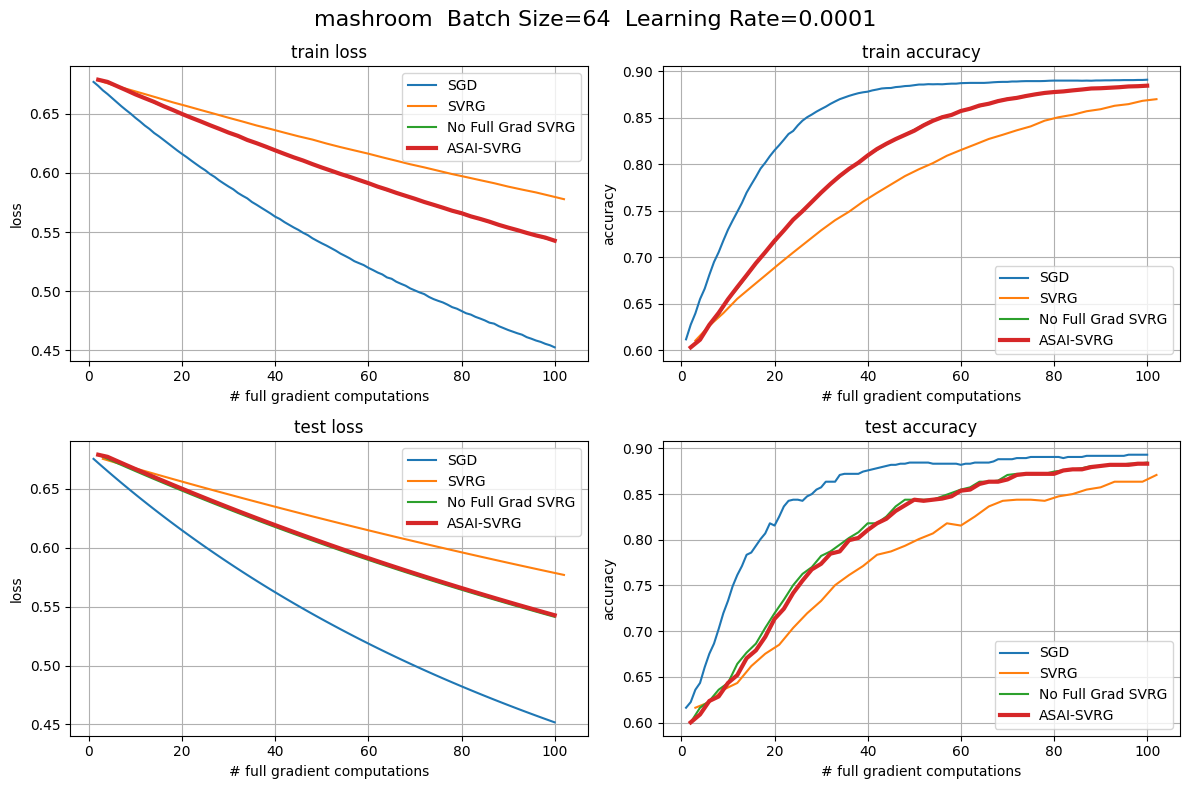

In [15]:
fig = plt.figure(figsize = (12, 8))
fig.suptitle(f"mashroom  Batch Size={BATCH_SIZE}  Learning Rate={LEARNING_RATE}",fontsize=16)
ax = fig.add_subplot(2, 2, 1)
ax.plot(SGD_x, SGD_train_loss_history, label = "SGD")
ax.plot(SVRG_x, SVRG_train_loss_history, label = "SVRG")
ax.plot(NFG_SVRG_x, NFG_SVRG_train_loss_history, label = "No Full Grad SVRG")
ax.plot(ASAI_SVRG_x, ASAI_SVRG_train_loss_history, label = "ASAI-SVRG", linewidth = 3)
ax.set_xlabel("# full gradient computations")
ax.set_ylabel("loss")
ax.set_title("train loss")
ax.grid()
ax.legend()

ax = fig.add_subplot(2, 2, 2)
ax.plot(SGD_x, SGD_train_acc_history, label = "SGD")
ax.plot(SVRG_x, SVRG_train_acc_history, label = "SVRG")
ax.plot(NFG_SVRG_x, NFG_SVRG_train_acc_history, label = "No Full Grad SVRG")
ax.plot(ASAI_SVRG_x, ASAI_SVRG_train_acc_history, label = "ASAI-SVRG", linewidth = 3)
ax.set_xlabel("# full gradient computations")
ax.set_ylabel("accuracy")
ax.set_title("train accuracy")
ax.grid()
ax.legend()

ax = fig.add_subplot(2, 2, 3)
ax.plot(SGD_x, SGD_test_loss_history, label = "SGD")
ax.plot(SVRG_x, SVRG_test_loss_history, label = "SVRG")
ax.plot(NFG_SVRG_x, NFG_SVRG_test_loss_history, label = "No Full Grad SVRG")
ax.plot(ASAI_SVRG_x, ASAI_SVRG_test_loss_history, label = "ASAI-SVRG", linewidth = 3)
ax.set_xlabel("# full gradient computations")
ax.set_ylabel("loss")
ax.set_title("test loss")
ax.grid()
ax.legend()

ax = fig.add_subplot(2, 2, 4)
ax.plot(SGD_x, SGD_test_acc_history, label = "SGD")
ax.plot(SVRG_x, SVRG_test_acc_history, label = "SVRG")
ax.plot(NFG_SVRG_x, NFG_SVRG_test_acc_history, label = "No Full Grad SVRG")
ax.plot(ASAI_SVRG_x, ASAI_SVRG_test_acc_history, label = "ASAI-SVRG", linewidth = 3)
ax.set_xlabel("# full gradient computations")
ax.set_ylabel("accuracy")
ax.set_title("test accuracy")
ax.grid()
ax.legend()

plt.tight_layout()
plt.show()